In [1]:
import numpy as np
import h5py
import re
import matplotlib.pyplot as plt
from pathlib import Path

Path("fig").mkdir(exist_ok=True)

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 12,
    "xtick.direction": "in",
    "ytick.direction": "in",
})

In [2]:
# -- Variable-step data (new top-level h5 layout; compatible with old segmented files) --
file_vs = "data/ns_SDIRK2_mr_SAV_bursting_30_3_4_vs.h5"

traj_keys = ["tn", "Energy", "Enstrophy", "Palinstrophy", "CPU_time"]
optional_traj_keys = ["Energy_rate", "Enstrophy_rate"]

def load_bursting_h5(path):
    """Load either the new top-level layout or the old segmented group layout."""
    with h5py.File(path, "r") as f:
        if "tn" in f and "Omega" in f:
            out = {
                "layout": "top-level",
                "tn": f["tn"][:],
                "tn_s": f["tn_s"][:],
                "tau": f["tau"][:] if "tau" in f else np.asarray(f.attrs.get("tau")),
                "Energy": f["Energy"][:],
                "Enstrophy": f["Enstrophy"][:],
                "Palinstrophy": f["Palinstrophy"][:],
                "CPU_time": f["CPU_time"][:],
                "Omega_shape": f["Omega"].shape,
            }
            for key in optional_traj_keys:
                if key in f:
                    out[key] = f[key][:]
            return out

        intervals = []
        for name in f.keys():
            m = re.match(r"t_([0-9.]+)_([0-9.]+)", name)
            if m:
                intervals.append((float(m.group(1)), float(m.group(2)), name))
        intervals.sort(key=lambda x: x[0])
        if not intervals:
            raise ValueError(f"No top-level datasets or t_* groups found in {path}")

        arrays = {k: [] for k in traj_keys}
        optional_arrays = {k: [] for k in optional_traj_keys}
        arrays["tn_s"] = []
        omega_count = 0
        omega_spatial_shape = None
        tau_list = []
        for i, (_, _, name) in enumerate(intervals):
            grp = f[name]
            skip = 1 if i > 0 else 0
            for k in traj_keys:
                arrays[k].append(grp[k][skip:])
            for k in optional_traj_keys:
                if k in grp:
                    optional_arrays[k].append(grp[k][skip:])
            arrays["tn_s"].append(grp["tn_s"][skip:])
            omega_count += grp["Omega"].shape[0] - skip
            omega_spatial_shape = grp["Omega"].shape[1:]
            if "tau" in grp:
                tau_list.append(grp["tau"][skip:])

        out = {
            "layout": "segmented",
            "segments": [name for _, _, name in intervals],
            **{k: np.concatenate(v) for k, v in arrays.items()},
            "Omega_shape": (omega_count, *omega_spatial_shape),
        }
        for k, chunks in optional_arrays.items():
            if chunks:
                out[k] = np.concatenate(chunks)
        if tau_list:
            out["tau"] = np.concatenate(tau_list)
        return out

def trapezoidal_point_weights(time):
    """Return node weights for time integrals on a nonuniform grid."""
    time = np.asarray(time, dtype=np.float64)
    if len(time) < 2:
        raise ValueError("At least two time points are required.")
    dt = np.diff(time)
    if np.any(dt <= 0):
        raise ValueError("Time points must be strictly increasing.")
    weights = np.empty_like(time)
    weights[0] = 0.5 * dt[0]
    weights[-1] = 0.5 * dt[-1]
    weights[1:-1] = 0.5 * (dt[:-1] + dt[1:])
    return weights

data_vs = load_bursting_h5(file_vs)
tn_vs        = data_vs["tn"]
tn_s_vs      = data_vs["tn_s"]
tau_vs       = data_vs["tau"]
Energy_vs    = data_vs["Energy"]
Energy_rate_vs = data_vs.get("Energy_rate")
Enstrophy_vs = data_vs["Enstrophy"]
Enstrophy_rate_vs = data_vs.get("Enstrophy_rate")
Palin_vs     = data_vs["Palinstrophy"]
CPU_vs       = data_vs["CPU_time"]

print(f"VS  | layout: {data_vs['layout']}")
print(f"VS  | tn:     {tn_vs.shape}, tn_s: {tn_s_vs.shape}, Omega: {data_vs['Omega_shape']}")
print(f"VS  | t range: [{tn_s_vs[0]:.3f}, {tn_s_vs[-1]:.3f}]")
print(f"VS  | tau range: [{tau_vs.min():.2e}, {tau_vs.max():.2e}]")
print(f"VS  | stored rates: Energy_rate={Energy_rate_vs is not None}, Enstrophy_rate={Enstrophy_rate_vs is not None}")


VS  | layout: top-level
VS  | tn:     (1359951,), tn_s: (1001,), Omega: (1001, 128, 128)
VS  | t range: [0.000, 10000.000]
VS  | tau range: [5.00e-04, 1.00e-02]
VS  | stored rates: Energy_rate=True, Enstrophy_rate=True


In [3]:
# -- Fixed-step data: load two fixed time-step runs without overwriting them --
fixed_step_files = {
    "tau=1e-3": {
        "path": "data/ns_SDIRK2_mr_SAV_bursting_30_3_4_0.001.h5",
        "tau": 1.0e-3,
    },
    "tau=5e-4": {
        "path": "data/ns_SDIRK2_mr_SAV_bursting_30_3_4_0.0005.h5",
        "tau": 5.0e-4,
    },
}

def summarize_bursting_run(label, data, path, tau_value=None):
    print(f"{label:<10} | file:   {path}")
    print(f"{label:<10} | layout: {data['layout']}")
    if data["layout"] == "segmented":
        print(f"{label:<10} | segments: {data['segments']}")
    print(
        f"{label:<10} | tn:     {data['tn'].shape}, "
        f"tn_s: {data['tn_s'].shape}, Omega: {data['Omega_shape']}"
    )
    print(f"{label:<10} | t range: [{data['tn_s'][0]:.3f}, {data['tn_s'][-1]:.3f}]")
    if tau_value is not None:
        print(f"{label:<10} | tau:    {tau_value:.1e}")
    print()

fs_runs = {}
for label, meta in fixed_step_files.items():
    fs_runs[label] = load_bursting_h5(meta["path"])
    fs_runs[label]["path"] = meta["path"]
    fs_runs[label]["tau_value"] = meta["tau"]
    summarize_bursting_run(label, fs_runs[label], meta["path"], meta["tau"])


tau=1e-3   | file:   data/ns_SDIRK2_mr_SAV_bursting_30_3_4_0.001.h5
tau=1e-3   | layout: top-level
tau=1e-3   | tn:     (10000001,), tn_s: (1001,), Omega: (1001, 128, 128)
tau=1e-3   | t range: [0.000, 10000.000]
tau=1e-3   | tau:    1.0e-03

tau=5e-4   | file:   data/ns_SDIRK2_mr_SAV_bursting_30_3_4_0.0005.h5
tau=5e-4   | layout: top-level
tau=5e-4   | tn:     (20000001,), tn_s: (1001,), Omega: (1001, 128, 128)
tau=5e-4   | t range: [0.000, 10000.000]
tau=5e-4   | tau:    5.0e-04



In [4]:
# -- Explicit aliases for the two fixed-step runs --
data_fs_1e3 = fs_runs["tau=1e-3"]
data_fs_5e4 = fs_runs["tau=5e-4"]

tn_fs_1e3        = data_fs_1e3["tn"]
tn_s_fs_1e3      = data_fs_1e3["tn_s"]
Energy_fs_1e3    = data_fs_1e3["Energy"]
Enstrophy_fs_1e3 = data_fs_1e3["Enstrophy"]
Palin_fs_1e3     = data_fs_1e3["Palinstrophy"]
CPU_fs_1e3       = data_fs_1e3["CPU_time"]
tau_fs_1e3       = data_fs_1e3["tau_value"]

tn_fs_5e4        = data_fs_5e4["tn"]
tn_s_fs_5e4      = data_fs_5e4["tn_s"]
Energy_fs_5e4    = data_fs_5e4["Energy"]
Enstrophy_fs_5e4 = data_fs_5e4["Enstrophy"]
Palin_fs_5e4     = data_fs_5e4["Palinstrophy"]
CPU_fs_5e4       = data_fs_5e4["CPU_time"]
tau_fs_5e4       = data_fs_5e4["tau_value"]

# Backward-compatible aliases below keep older cells usable; new comparisons use fixed_run_specs.
default_fs_key = "tau=1e-3"
data_fs = fs_runs[default_fs_key]
tau_fs = data_fs["tau_value"]

tn_fs        = data_fs["tn"]
tn_s_fs      = data_fs["tn_s"]
Energy_fs    = data_fs["Energy"]
Enstrophy_fs = data_fs["Enstrophy"]
Palin_fs     = data_fs["Palinstrophy"]
CPU_fs       = data_fs["CPU_time"]

print(f"Default fixed-step reference: {default_fs_key} (tau = {tau_fs:.1e})")


# Shared labels and colors for all comparisons.
fixed_run_specs = {
    "tau=1e-3": {
        "data": data_fs_1e3,
        "tau_value": tau_fs_1e3,
        "color": "C3",
        "label": r"Fixed step ($\tau=10^{-3}$)",
        "short_label": r"$\tau=10^{-3}$",
    },
    "tau=5e-4": {
        "data": data_fs_5e4,
        "tau_value": tau_fs_5e4,
        "color": "#6A5ACD",
        "label": r"Fixed step ($\tau=5\times10^{-4}$)",
        "short_label": r"$\tau=5\times10^{-4}$",
    },
}
adaptive_spec = {
    "data": data_vs,
    "color": "#2E8B57",
    "label": r"Adaptive step",
    "short_label": r"Adaptive",
}


Default fixed-step reference: tau=1e-3 (tau = 1.0e-03)


In [5]:
# ── Representative flow scales from time-averaged kinetic energy ──────────
#
# Energy is defined in the solver as
#   E(t) = 1/2 ||u(.,t)||_{L2(Ω)}^2.
# For Ω = [0,L]^2 with L = 2π, define the representative velocity by
#   U = sqrt( 2/(L^2 T) * int_0^T E(t) dt ),
# and then set
#   Re = U L / ν,   T_e = L / U.
#
# Thus U, Re, and T_e are representative constants over the averaging window,
# not instantaneous time series.

L_domain = 2 * np.pi
nu = 1 / 40
t_flow_start = 1000.0
t_flow_end = 10000.0

def integrate_over_window(time, values, t0, t1):
    time = np.asarray(time, dtype=np.float64)
    values = np.asarray(values, dtype=np.float64)

    order = np.argsort(time)
    time = time[order]
    values = values[order]

    finite = np.isfinite(time) & np.isfinite(values)
    time = time[finite]
    values = values[finite]

    # Remove duplicated segment boundaries before interpolating endpoints.
    time, unique_idx = np.unique(time, return_index=True)
    values = values[unique_idx]

    if t0 < time[0] or t1 > time[-1]:
        raise ValueError(
            f"Requested window [{t0}, {t1}] is outside the data range "
            f"[{time[0]}, {time[-1]}]."
        )

    interior = (time > t0) & (time < t1)
    t_window = np.concatenate(([t0], time[interior], [t1]))
    v_window = np.concatenate((
        [np.interp(t0, time, values)],
        values[interior],
        [np.interp(t1, time, values)],
    ))
    return np.trapezoid(v_window, t_window)

def representative_flow_scales(time, energy, t0=t_flow_start, t1=t_flow_end,
                               L=L_domain, nu=nu):
    window_length = t1 - t0
    if window_length <= 0:
        raise ValueError("The averaging window must have positive length.")

    energy_integral = integrate_over_window(time, energy, t0, t1)
    mean_energy = energy_integral / window_length
    U = np.sqrt(max(2 * mean_energy / L**2, 0.0))
    Re = U * L / nu
    Te = np.inf if U == 0 else L / U
    return {
        "energy_integral": energy_integral,
        "mean_energy": mean_energy,
        "U": U,
        "Re": Re,
        "Te": Te,
    }

def relative_difference(value, reference):
    return (value - reference) / reference

flow_scales_fixed = {
    key: representative_flow_scales(spec["data"]["tn"], spec["data"]["Energy"])
    for key, spec in fixed_run_specs.items()
}
flow_scales_vs = representative_flow_scales(tn_vs, Energy_vs)

# Backward-compatible default fixed-step aliases.
flow_scales_fs = flow_scales_fixed[default_fs_key]

rows = [
    (r"U", "U"),
    (r"Re", "Re"),
    (r"T_e", "Te"),
    (r"<E>", "mean_energy"),
    (r"int E dt", "energy_integral"),
]

print(f"Representative flow scales from {t_flow_start:g} <= t <= {t_flow_end:g}")
print("─" * 112)
print(
    f"{'Quantity':<12} {'Fixed 1e-3':>14} {'Fixed 5e-4':>14} "
    f"{'Adaptive':>14} {'Ada.-1e-3':>13} {'Ada.-5e-4':>13}"
)
print("─" * 112)
for label, key in rows:
    fs_1e3 = flow_scales_fixed["tau=1e-3"][key]
    fs_5e4 = flow_scales_fixed["tau=5e-4"][key]
    vs_value = flow_scales_vs[key]
    rel_1e3 = 100 * relative_difference(vs_value, fs_1e3)
    rel_5e4 = 100 * relative_difference(vs_value, fs_5e4)
    print(
        f"{label:<12} {fs_1e3:>14.6f} {fs_5e4:>14.6f} "
        f"{vs_value:>14.6f} {rel_1e3:>12.3f}% {rel_5e4:>12.3f}%"
    )
print("─" * 112)


Representative flow scales from 1000 <= t <= 10000
────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Quantity         Fixed 1e-3     Fixed 5e-4       Adaptive     Ada.-1e-3     Ada.-5e-4
────────────────────────────────────────────────────────────────────────────────────────────────────────────────
U                  1.346111       1.342826       1.344536       -0.117%        0.127%
Re               338.314501     337.489029     337.918640       -0.117%        0.127%
T_e                4.667659       4.679076       4.673127        0.117%       -0.127%
<E>               35.767719      35.593389      35.684065       -0.234%        0.255%
int E dt      321909.472957  320340.501243  321156.583663       -0.234%        0.255%
────────────────────────────────────────────────────────────────────────────────────────────────────────────────


In [6]:
# ── Common plotting strides ────────────────────────────────────────────────
# Downsample dense time series only for plotting.
stride_fs = 500   # tn_fs has ~10^7 points -> keep ~20000
stride_vs = 50    # tn_vs has ~1.5×10^6 points -> keep ~30000

In [7]:
# ── Adaptive-step tau 与诊断量及其变化率的相关性 ───────────────────────────
#
# Compute correlations between tau and selected diagnostics X, and between tau
# and the available first-rate diagnostics. Higher-order finite-difference rates
# are intentionally omitted because they are noisy and not needed here.

t_corr = np.asarray(data_vs["tn"], dtype=np.float64)
tau_corr = np.asarray(data_vs["tau"], dtype=np.float64)

def align_tau_to_points(tau, t):
    tau = np.asarray(tau, dtype=np.float64)
    if len(tau) == len(t):
        return tau
    if len(tau) == len(t) - 1:
        return np.concatenate([tau, [tau[-1]]])
    raise ValueError(f"Cannot align tau with values: len(tau)={len(tau)}, len(t)={len(t)}")

tau_point_corr = align_tau_to_points(tau_corr, t_corr)

if len(tau_corr) == len(t_corr):
    tau_rate_corr = tau_corr[:-1]
elif len(tau_corr) == len(t_corr) - 1:
    tau_rate_corr = tau_corr
else:
    raise ValueError(
        f"Cannot align tau with rates: len(tau)={len(tau_corr)}, len(t)={len(t_corr)}"
    )

dt_corr = np.diff(t_corr)
t_mid_corr = 0.5 * (t_corr[:-1] + t_corr[1:])

print(f"max |tau_rate - dt| = {np.nanmax(np.abs(tau_rate_corr - dt_corr)):.3e}")

def pearson_corr(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    if len(x) < 2 or np.std(x) == 0 or np.std(y) == 0:
        return np.nan
    return np.corrcoef(x, y)[0, 1]

def weighted_corr(x, y, w):
    x = np.asarray(x)
    y = np.asarray(y)
    w = np.asarray(w)
    mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(w) & (w > 0)
    x, y, w = x[mask], y[mask], w[mask]
    if len(x) < 2:
        return np.nan
    mx = np.average(x, weights=w)
    my = np.average(y, weights=w)
    vx = np.average((x - mx) ** 2, weights=w)
    vy = np.average((y - my) ** 2, weights=w)
    if vx <= 0 or vy <= 0:
        return np.nan
    cov = np.average((x - mx) * (y - my), weights=w)
    return cov / np.sqrt(vx * vy)

def finite_difference_rate(values):
    values = np.asarray(values, dtype=np.float64)
    return np.diff(values) / dt_corr

def stored_or_fallback_rate(data, value_key, rate_key):
    if rate_key in data and len(data[rate_key]) == len(t_corr):
        return np.asarray(data[rate_key], dtype=np.float64), t_corr, tau_point_corr, tau_point_corr, "stored"
    return finite_difference_rate(data[value_key]), t_mid_corr, tau_rate_corr, dt_corr, "finite difference"

def corr_row(window_name, name, values, time, tau_values, weights, transform=lambda x: x):
    values = transform(np.asarray(values, dtype=np.float64))
    mask = (
        np.asarray(time) >= windows_corr[window_name]
        if window_name in windows_corr
        else np.ones_like(values, dtype=bool)
    )
    mask = mask & np.isfinite(values) & np.isfinite(tau_values) & np.isfinite(weights) & (weights > 0)
    return {
        "window": window_name,
        "quantity": name,
        "N": int(np.count_nonzero(mask)),
        "corr(quantity, tau)": pearson_corr(values[mask], tau_values[mask]),
        "weighted corr(quantity, tau)": weighted_corr(values[mask], tau_values[mask], weights[mask]),
        "source": "",
    }

windows_corr = {
    "Full interval": -np.inf,
    "t >= 1000": 1000.0,
}

tau_correlation_rows = []
for window_name in windows_corr:
    for name, values in {
        "Energy": data_vs["Energy"],
        "Enstrophy": data_vs["Enstrophy"],
        "Palinstrophy": data_vs["Palinstrophy"],
    }.items():
        tau_correlation_rows.append(
            corr_row(window_name, name, values, t_corr, tau_point_corr, tau_point_corr)
        )

    for name, value_key, rate_key in [
        ("|Energy rate|", "Energy", "Energy_rate"),
        ("|Enstrophy rate|", "Enstrophy", "Enstrophy_rate"),
    ]:
        rate_values, rate_time, rate_tau, rate_weights, rate_source = stored_or_fallback_rate(data_vs, value_key, rate_key)
        row = corr_row(window_name, name, rate_values, rate_time, rate_tau, rate_weights, transform=np.abs)
        row["source"] = rate_source
        tau_correlation_rows.append(row)

print("Correlation between adaptive tau and diagnostics / first rates")
print("─" * 100)

def print_tau_correlation_rows(rows):
    header = f"{'window':<14} {'quantity':<18} {'N':>9} {'corr':>11} {'weighted corr':>15} {'source':>18}"
    print(header)
    print("-" * len(header))
    for row in rows:
        print(
            f"{row['window']:<14} {row['quantity']:<18} {row['N']:>9d} "
            f"{row['corr(quantity, tau)']:>11.6f} {row['weighted corr(quantity, tau)']:>15.6f} "
            f"{row.get('source', ''):>18}"
        )

try:
    import pandas as pd
    tau_correlation_table = pd.DataFrame(tau_correlation_rows)
    try:
        from IPython.display import display as ipy_display
        ipy_display(tau_correlation_table.style.format({
            "corr(quantity, tau)": "{:.6f}",
            "weighted corr(quantity, tau)": "{:.6f}",
        }))
    except ImportError:
        print(tau_correlation_table.to_string(index=False))
except ImportError:
    tau_correlation_table = tau_correlation_rows
    print_tau_correlation_rows(tau_correlation_rows)


max |tau_rate - dt| = 9.095e-13
Correlation between adaptive tau and diagnostics / first rates
────────────────────────────────────────────────────────────────────────────────────────────────────


,window,quantity,N,"corr(quantity, tau)","weighted corr(quantity, tau)",source
0,Full interval,Energy,1359951,-0.194881,-0.167561,
1,Full interval,Enstrophy,1359951,-0.375024,-0.443253,
2,Full interval,Palinstrophy,1359951,-0.607154,-0.621667,
3,Full interval,|Energy rate|,1359951,-0.274310,-0.295230,stored
4,Full interval,|Enstrophy rate|,1359951,-0.464892,-0.469961,stored
5,t >= 1000,Energy,1218309,-0.536589,-0.502505,
6,t >= 1000,Enstrophy,1218309,-0.558105,-0.548946,
7,t >= 1000,Palinstrophy,1218309,-0.645057,-0.633195,
8,t >= 1000,|Energy rate|,1218309,-0.489141,-0.468199,stored
9,t >= 1000,|Enstrophy rate|,1218309,-0.508557,-0.481767,stored


In [8]:
# ── 时间加权 KDE（500 <= t <= 10000）───────────────────────────────────────
#
# gaussian_kde 的 weights 参数直接接受非均匀权重：
#   固定步长：等权重
#   变步长  ：weights = tau_vs，每个采样点按实际步长加权
#
# 两组固定步长数据按相近的物理时间间隔降采样，避免 KDE 点数差异过大。

from scipy.stats import gaussian_kde

kde_t_start = 1000.0
kde_t_end = 10000.0
fixed_kde_dt = 2.0e-2

# ── 固定步长稳态数据 ───────────────────────────────────────────────────────
fixed_kde_data = {}
fixed_kdes = {}
fixed_pdfs = {}

for label, data in fs_runs.items():
    tau_value = data["tau_value"]
    i0 = int(np.searchsorted(data["tn"], kde_t_start, side="left"))
    i1 = int(np.searchsorted(data["tn"], kde_t_end, side="right"))
    stride_kde = max(1, int(round(fixed_kde_dt / tau_value)))
    samples = data["Enstrophy"][i0:i1:stride_kde]
    fixed_kde_data[label] = samples
    fixed_kdes[label] = gaussian_kde(samples)
    print(
        f"{label:<10} KDE points : {len(samples):,} "
        f"(window=[{kde_t_start:g}, {kde_t_end:g}], stride={stride_kde}, tau={tau_value:.1e})"
    )

# ── 变步长稳态数据 ─────────────────────────────────────────────────────────
mask_vs = (tn_vs >= kde_t_start) & (tn_vs <= kde_t_end)
E_vs_ss = Enstrophy_vs[mask_vs]
w_vs    = trapezoidal_point_weights(tn_vs[mask_vs])

print(f"Adaptive   KDE points : {len(E_vs_ss):,}  (weighted by tau_vs, window=[{kde_t_start:g}, {kde_t_end:g}])")

# ── KDE ──────────────────────────────────────────────────────────────────
kde_vs = gaussian_kde(E_vs_ss, weights=w_vs)

Z_grid = np.linspace(0, 500, 2501)
for label, kde in fixed_kdes.items():
    fixed_pdfs[label] = kde(Z_grid)
pdf_vs = kde_vs(Z_grid)

# Backward-compatible names used by later analysis cells.
kde_fs = fixed_kdes[default_fs_key]
pdf_fs = fixed_pdfs[default_fs_key]
E_fs_ss = fixed_kde_data[default_fs_key]


tau=1e-3   KDE points : 450,001 (window=[1000, 10000], stride=20, tau=1.0e-03)
tau=5e-4   KDE points : 450,001 (window=[1000, 10000], stride=40, tau=5.0e-04)
Adaptive   KDE points : 1,218,309  (weighted by tau_vs, window=[1000, 10000])


In [9]:
# ── 时间加权统计矩（稳态，t > 1000）─────────────────────────────────────────
#
# 固定步长：等权重，np.average / np.var 直接计算
# 变步长  ：weights = tau_vs，np.average(x, weights=w) = Σ(x_i·w_i)/Σw_i

t_cutoff = 1000

def weighted_moments(x, w=None):
    """返回 (均值, 二阶原点矩, 方差, 标准差)。"""
    mu1 = np.average(x, weights=w)
    mu2 = np.average(x**2, weights=w)
    var = np.average((x - mu1)**2, weights=w)
    std = np.sqrt(var)
    return mu1, mu2, var, std

def steady_enstrophy_samples_fixed(data, t0=t_cutoff):
    i0 = int(np.searchsorted(data["tn"], t0, side="left"))
    return data["Enstrophy"][i0:]

def steady_enstrophy_samples_adaptive(t0=t_cutoff):
    mask = tn_vs >= t0
    return Enstrophy_vs[mask], trapezoidal_point_weights(tn_vs[mask])

steady_moments_fixed = {}
for key, spec in fixed_run_specs.items():
    samples = steady_enstrophy_samples_fixed(spec["data"])
    mu1, mu2, var, std = weighted_moments(samples)
    steady_moments_fixed[key] = {
        "samples": samples,
        "mean": mu1,
        "second_moment": mu2,
        "variance": var,
        "std": std,
    }

E_vs_ss, w_vs = steady_enstrophy_samples_adaptive()
mu1_vs, mu2_vs, var_vs, std_vs = weighted_moments(E_vs_ss, w=w_vs)
steady_moments_vs = {
    "samples": E_vs_ss,
    "weights": w_vs,
    "mean": mu1_vs,
    "second_moment": mu2_vs,
    "variance": var_vs,
    "std": std_vs,
}

# Backward-compatible default fixed-step aliases used by later cells.
E_fs_ss = steady_moments_fixed[default_fs_key]["samples"]
mu1_fs = steady_moments_fixed[default_fs_key]["mean"]
mu2_fs = steady_moments_fixed[default_fs_key]["second_moment"]
var_fs = steady_moments_fixed[default_fs_key]["variance"]
std_fs = steady_moments_fixed[default_fs_key]["std"]

moment_rows = [
    ("Mean E[Z]", "mean"),
    ("Second moment E[Z^2]", "second_moment"),
    ("Variance Var[Z]", "variance"),
    ("Std[Z]", "std"),
]

print("Steady-state enstrophy moments on t >= 1000")
print("─" * 118)
print(
    f"{'Statistic':<24} {'Fixed 1e-3':>16} {'Fixed 5e-4':>16} "
    f"{'Adaptive':>16} {'Ada.-1e-3':>14} {'Ada.-5e-4':>14}"
)
print("─" * 118)
for label, key in moment_rows:
    fs_1e3 = steady_moments_fixed["tau=1e-3"][key]
    fs_5e4 = steady_moments_fixed["tau=5e-4"][key]
    vs_value = steady_moments_vs[key]
    rel_1e3 = 100 * (vs_value - fs_1e3) / fs_1e3
    rel_5e4 = 100 * (vs_value - fs_5e4) / fs_5e4
    print(
        f"{label:<24} {fs_1e3:>16.4f} {fs_5e4:>16.4f} "
        f"{vs_value:>16.4f} {rel_1e3:>13.3f}% {rel_5e4:>13.3f}%"
    )
print("─" * 118)


Steady-state enstrophy moments on t >= 1000
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Statistic                      Fixed 1e-3       Fixed 5e-4         Adaptive      Ada.-1e-3      Ada.-5e-4
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Mean E[Z]                        115.8992         113.3578         116.4391         0.466%         2.718%
Second moment E[Z^2]           15971.2661       15284.8955       16063.0899         0.575%         5.091%
Variance Var[Z]                 2538.6423        2434.9027        2505.0259        -1.324%         2.880%
Std[Z]                            50.3849          49.3447          50.0502        -0.664%         1.430%
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


In [10]:
# ── Total Variation Distance & 相对 L1 范数（稳态 KDE）───────────────────────
#
# 对每个固定步长 KDE 分别与自适应步长的时间加权 KDE 进行比较。

from scipy.stats import gaussian_kde

N_GRID = 2501

def ensure_enstrophy_kdes(t0=1000.0, t1=10000.0, fixed_dt=2.0e-2):
    """Create KDE objects if the KDE cell has not been run in this kernel."""
    global fixed_kde_data, fixed_kdes, fixed_pdfs, kde_vs, Z_grid, pdf_vs
    if all(name in globals() for name in ["fixed_kdes", "fixed_pdfs", "kde_vs", "Z_grid", "pdf_vs"]):
        return

    fixed_kde_data = {}
    fixed_kdes = {}
    fixed_pdfs = {}
    for key, spec in fixed_run_specs.items():
        data = spec["data"]
        tau_value = data["tau_value"]
        i0 = int(np.searchsorted(data["tn"], t0, side="left"))
        i1 = int(np.searchsorted(data["tn"], t1, side="right"))
        stride_kde = max(1, int(round(fixed_dt / tau_value)))
        samples = data["Enstrophy"][i0:i1:stride_kde]
        fixed_kde_data[key] = samples
        fixed_kdes[key] = gaussian_kde(samples)

    mask_vs = (tn_vs >= t0) & (tn_vs <= t1)
    E_vs = Enstrophy_vs[mask_vs]
    w_vs_local = trapezoidal_point_weights(tn_vs[mask_vs])
    kde_vs = gaussian_kde(E_vs, weights=w_vs_local)

    Z_grid = np.linspace(0, 500, N_GRID)
    for key, kde in fixed_kdes.items():
        fixed_pdfs[key] = kde(Z_grid)
    pdf_vs = kde_vs(Z_grid)

ensure_enstrophy_kdes(t0=kde_t_start if "kde_t_start" in globals() else 1000.0, 
                      t1=kde_t_end if "kde_t_end" in globals() else 10000.0)

# Backward-compatible default fixed-step aliases.
kde_fs = fixed_kdes[default_fs_key]
pdf_fs = fixed_pdfs[default_fs_key]

def interval_metrics(z, p, q, a, b):
    mask = (z >= a) & (z <= b)
    z_interval = z[mask]
    p_interval = p[mask]
    q_interval = q[mask]
    mass_p = np.trapezoid(p_interval, z_interval)
    mass_q = np.trapezoid(q_interval, z_interval)
    l1 = np.trapezoid(np.abs(p_interval - q_interval), z_interval)
    tvd = 0.5 * l1
    rel_l1 = l1 / (0.5 * (mass_p + mass_q)) if (mass_p + mass_q) > 0 else np.nan
    return mass_p, mass_q, tvd, rel_l1

intervals = [
    ("(0,   120)", 0, 120),
    ("(120, 400)", 120, 400),
    ("(0,   500)", 0, 500),
]

print("KDE distance between each fixed-step run and the adaptive run")
print("─" * 102)
print(f"{'Fixed run':<12} {'Interval':<14} {'P_fixed':>9} {'P_adapt':>9} {'TVD':>12} {'Rel. L1':>12}")
print("─" * 102)
for key, spec in fixed_run_specs.items():
    for interval_label, a, b in intervals:
        mass_p, mass_q, tvd, rel_l1 = interval_metrics(
            Z_grid, fixed_pdfs[key], pdf_vs, a, b
        )
        print(
            f"{key:<12} {interval_label:<14} {mass_p:>9.4f} {mass_q:>9.4f} "
            f"{tvd:>12.6f} {rel_l1:>12.6f}"
        )
print("─" * 102)
print("P_fixed/P_adapt are probability masses on the selected interval.")
print("TVD = (1/2)∫|p_fixed-p_adapt| dx; Rel. L1 normalizes by the mean interval mass.")


KDE distance between each fixed-step run and the adaptive run
──────────────────────────────────────────────────────────────────────────────────────────────────────
Fixed run    Interval         P_fixed   P_adapt          TVD      Rel. L1
──────────────────────────────────────────────────────────────────────────────────────────────────────
tau=1e-3     (0,   120)        0.6574    0.6437     0.014896     0.045796
tau=1e-3     (120, 400)        0.3426    0.3563     0.020139     0.115260
tau=1e-3     (0,   500)        1.0000    1.0000     0.035035     0.070070
tau=5e-4     (0,   120)        0.6761    0.6437     0.017623     0.053411
tau=5e-4     (120, 400)        0.3239    0.3563     0.019542     0.114916
tau=5e-4     (0,   500)        1.0000    1.0000     0.037165     0.074329
──────────────────────────────────────────────────────────────────────────────────────────────────────
P_fixed/P_adapt are probability masses on the selected interval.
TVD = (1/2)∫|p_fixed-p_adapt| dx; Rel. L1 norm

In [11]:
# ── Fixed-step KDE comparison：tau=1e-3 vs tau=5e-4 ───────────────────────
#
# Compare the two fixed-step steady-state KDEs directly, using the same
# intervals and distance definitions as the adaptive-vs-fixed comparison.

from scipy.stats import gaussian_kde

if "ensure_enstrophy_kdes" in globals():
    ensure_enstrophy_kdes(
        t0=kde_t_start if "kde_t_start" in globals() else 1000.0,
        t1=kde_t_end if "kde_t_end" in globals() else 10000.0,
    )
elif "fixed_kdes" not in globals():
    fixed_kde_data = {}
    fixed_kdes = {}
    fixed_t0 = kde_t_start if "kde_t_start" in globals() else 1000.0
    fixed_t1 = kde_t_end if "kde_t_end" in globals() else 10000.0
    fixed_dt = fixed_kde_dt if "fixed_kde_dt" in globals() else 2.0e-2
    for key, spec in fixed_run_specs.items():
        data = spec["data"]
        tau_value = data["tau_value"]
        i0 = int(np.searchsorted(data["tn"], fixed_t0, side="left"))
        i1 = int(np.searchsorted(data["tn"], fixed_t1, side="right"))
        stride_kde = max(1, int(round(fixed_dt / tau_value)))
        samples = data["Enstrophy"][i0:i1:stride_kde]
        fixed_kde_data[key] = samples
        fixed_kdes[key] = gaussian_kde(samples)

N_GRID_FIXED_COMPARE = N_GRID if "N_GRID" in globals() else 5000

if "interval_metrics" not in globals():
    def interval_metrics(z, p, q, a, b):
        mask = (z >= a) & (z <= b)
        z_interval = z[mask]
        p_interval = p[mask]
        q_interval = q[mask]
        mass_p = np.trapezoid(p_interval, z_interval)
        mass_q = np.trapezoid(q_interval, z_interval)
        l1 = np.trapezoid(np.abs(p_interval - q_interval), z_interval)
        tvd = 0.5 * l1
        rel_l1 = l1 / (0.5 * (mass_p + mass_q)) if (mass_p + mass_q) > 0 else np.nan
        return mass_p, mass_q, tvd, rel_l1

if "intervals" not in globals():
    intervals = [
        ("(0,   120)", 0, 120),
        ("(120, 400)", 120, 400),
        ("(0,   500)", 0, 500),
    ]

fixed_a = "tau=1e-3"
fixed_b = "tau=5e-4"

print(f"KDE distance between fixed-step runs: {fixed_a} vs {fixed_b}")
print("─" * 100)
print(f"{'Interval':<14} {'P_1e-3':>10} {'P_5e-4':>10} {'TVD':>12} {'Rel. L1':>12}")
print("─" * 100)
for interval_label, a, b in intervals:
    mass_a, mass_b, tvd, rel_l1 = interval_metrics(
        Z_grid, fixed_pdfs[fixed_a], fixed_pdfs[fixed_b], a, b
    )
    print(
        f"{interval_label:<14} {mass_a:>10.4f} {mass_b:>10.4f} "
        f"{tvd:>12.6f} {rel_l1:>12.6f}"
    )
print("─" * 100)
print("P_1e-3/P_5e-4 are probability masses on the selected interval.")
print("TVD = (1/2)∫|p_1e-3-p_5e-4| dx; Rel. L1 normalizes by the mean interval mass.")


KDE distance between fixed-step runs: tau=1e-3 vs tau=5e-4
────────────────────────────────────────────────────────────────────────────────────────────────────
Interval           P_1e-3     P_5e-4          TVD      Rel. L1
────────────────────────────────────────────────────────────────────────────────────────────────────
(0,   120)         0.6574     0.6761     0.020334     0.060995
(120, 400)         0.3426     0.3239     0.012600     0.075618
(0,   500)         1.0000     1.0000     0.032934     0.065868
────────────────────────────────────────────────────────────────────────────────────────────────────
P_1e-3/P_5e-4 are probability masses on the selected interval.
TVD = (1/2)∫|p_1e-3-p_5e-4| dx; Rel. L1 normalizes by the mean interval mass.


CPU time scale: ×1
CPU slope fitting window: [3000, 7000]
Dashed-line visual offset: 0.395 h
Adaptive slope : 0.0001 h/t   (intercept 0.004)
tau=1e-3   slope : 0.0008 h/t   speedup vs adaptive: 7.06×
tau=5e-4   slope : 0.0016 h/t   speedup vs adaptive: 13.99×


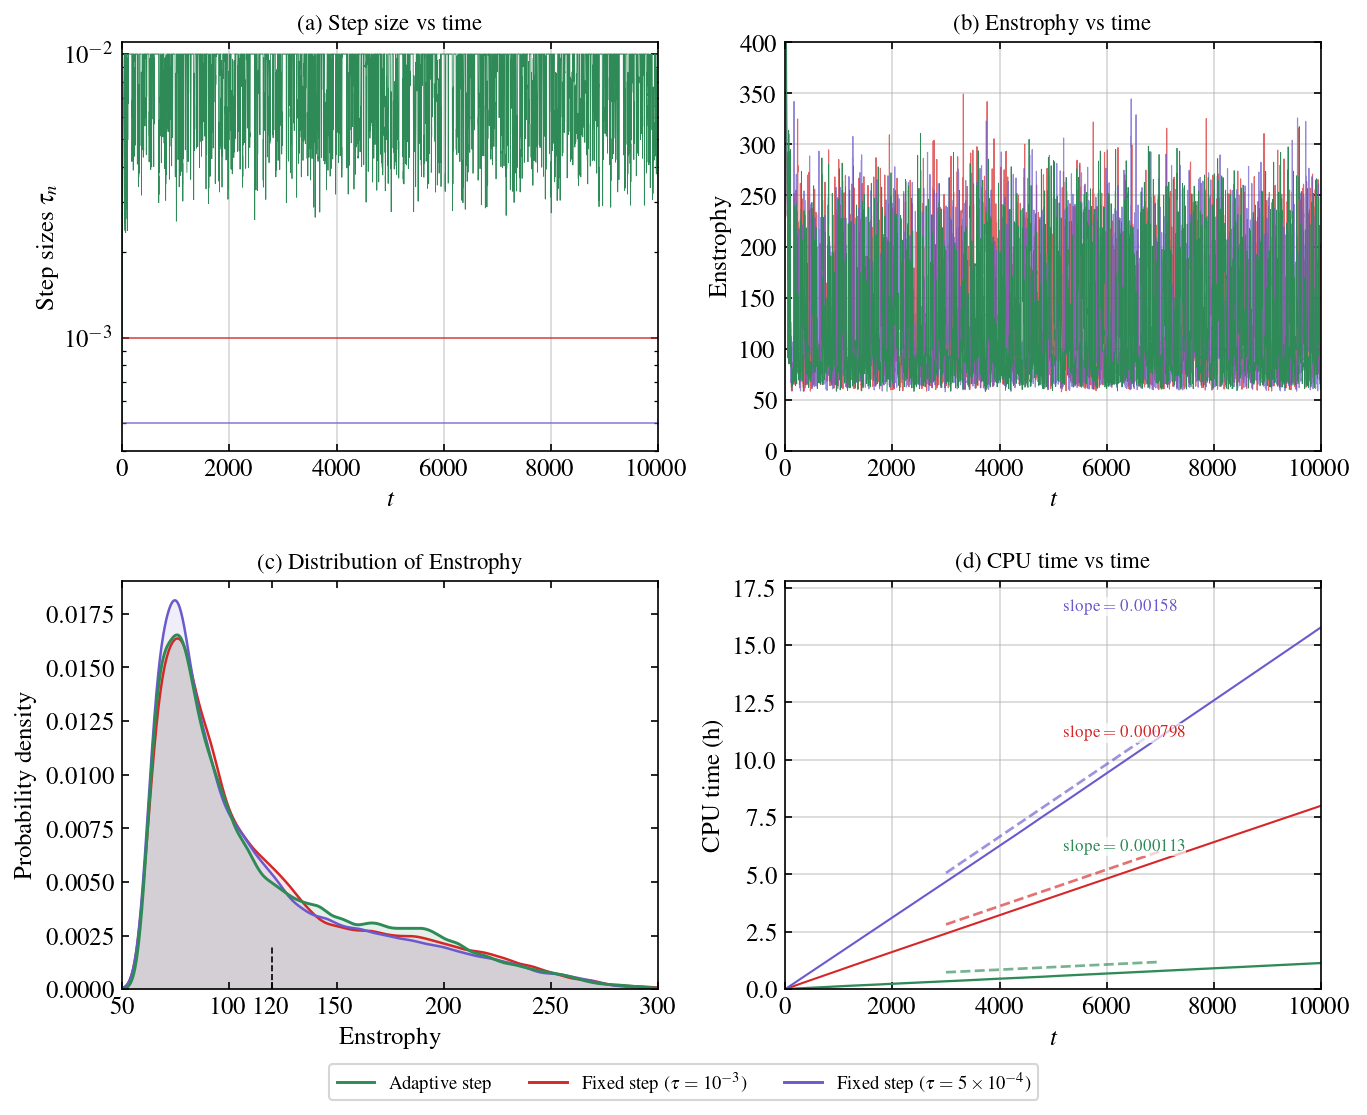

In [17]:
# ── Variable-step 自适应步长诊断：2×2 子图 ──────────────────────────────────
#
# (a) 步长 τ 随时间变化
# (b) Enstrophy 随时间变化
# (c) Enstrophy distribution comparison
# (d) 物理时间 t 与 CPU time 的关系

stride = 100   # 1.5×10^6 → ~30000 点，足够线图

t   = tn_vs[::stride]
t_tau = tn_vs[:len(tau_vs):stride]
tau = tau_vs[::stride]
E   = Enstrophy_vs[::stride]

fixed_plot_specs = fixed_run_specs
adaptive_color = adaptive_spec["color"]
adaptive_label = adaptive_spec["label"]

if "fixed_pdfs" not in globals() or "pdf_vs" not in globals() or "Z_grid" not in globals():
    from scipy.stats import gaussian_kde
    fixed_kde_data = {}
    fixed_kdes = {}
    fixed_pdfs = {}
    for key, spec in fixed_run_specs.items():
        data = spec["data"]
        tau_value = data["tau_value"]
        i0 = int(np.searchsorted(data["tn"], 1000.0, side="left"))
        i1 = int(np.searchsorted(data["tn"], 10000.0, side="right"))
        stride_kde = max(1, int(round(2.0e-2 / tau_value)))
        samples = data["Enstrophy"][i0:i1:stride_kde]
        fixed_kde_data[key] = samples
        fixed_kdes[key] = gaussian_kde(samples)
    mask_vs_kde = (tn_vs >= 1000.0) & (tn_vs <= 10000.0)
    kde_vs = gaussian_kde(
        Enstrophy_vs[mask_vs_kde],
        weights=trapezoidal_point_weights(tn_vs[mask_vs_kde]),
    )
    Z_grid = np.linspace(50, 1500, 2000)
    for key, kde in fixed_kdes.items():
        fixed_pdfs[key] = kde(Z_grid)
    pdf_vs = kde_vs(Z_grid)

fig, axes = plt.subplots(2, 2, figsize=(9, 7), constrained_layout=True, dpi=150)
fig.set_constrained_layout_pads(h_pad=0.05, hspace=0.08)

# ── (a) 步长随时间变化 ──────────────────────────────────────────────────────
ax = axes[0, 0]
for spec in fixed_plot_specs.values():
    tau_value = spec["data"]["tau_value"]
    ax.hlines(
        tau_value, 0, 10000,
        color=spec["color"], linewidth=0.8, alpha=0.75, linestyle="-",
        rasterized=True,
    )
ax.plot(t_tau, tau, color=adaptive_color, linewidth=0.4, rasterized=True)
ax.set_yscale("log")
ax.set_xlim(0, 10000)
ax.set_ylim(4.0e-4, max(1.2e-3, 1.1 * np.nanmax(tau)))
ax.set_xlabel(r"$t$")
ax.set_ylabel(r"Step sizes $\tau_n$")
ax.set_title(r"(a) Step size vs time", loc="center", fontsize=11)
ax.tick_params(which="both", direction="in", top=True, right=True)
ax.grid(alpha=0.5)

# ── (b) Enstrophy 随时间变化 ────────────────────────────────────────────────
ax = axes[0, 1]
for spec in fixed_plot_specs.values():
    data = spec["data"]
    stride_fixed = max(1, len(data["tn"]) // 20000)
    ax.plot(
        data["tn"][::stride_fixed],
        data["Enstrophy"][::stride_fixed],
        color=spec["color"], alpha=0.70, linewidth=0.55,
        rasterized=True,
    )
ax.plot(t, E, color=adaptive_color, linewidth=0.4, rasterized=True)
ax.set_xlim(0, 10000)
ax.set_ylim(0, 400)
ax.set_xlabel(r"$t$")
ax.set_ylabel(r"Enstrophy")
ax.set_title(r"(b) Enstrophy vs time", loc="center", fontsize=11)
ax.tick_params(which="both", direction="in", top=True, right=True)
ax.grid(alpha=0.5)

# ── (c) Enstrophy distribution comparison ────────────────────────────────
ax = axes[1, 0]
ax.vlines(120, 0, 0.002, color="k", linestyles="--", linewidth=0.8)
for key, spec in fixed_plot_specs.items():
    pdf = fixed_pdfs[key]
    ax.fill_between(Z_grid, pdf, color=spec["color"], alpha=0.10, linewidth=0)
    ax.plot(Z_grid, pdf, color=spec["color"], linewidth=1.2)
ax.fill_between(Z_grid, pdf_vs, color=adaptive_color, alpha=0.12, linewidth=0)
ax.plot(Z_grid, pdf_vs, color=adaptive_color, linewidth=1.4)

ax.set_xticks([50, 100, 120, 150, 200, 250, 300])
ax.set_xlim(50, 300)
ax.set_ylim(bottom=0)
ax.set_xlabel(r"Enstrophy")
ax.set_ylabel(r"Probability density")
ax.set_title(r"(c) Distribution of Enstrophy", fontsize=11)
ax.tick_params(which="both", direction="in", top=True, right=True)

# ── (d) 物理时间 t 与 CPU time 的关系 ──────────────────────────────────────
ax = axes[1, 1]

# All three runs use the same N=128 resolution, so compare their recorded CPU
# times directly without resolution or per-run calibration factors.
cpu_time_scale = 1.0
cpu_time_factors = {
    "adaptive": 1.0,
    "tau=1e-3": 1.0,
    "tau=5e-4": 1.0,
}
fit_t0, fit_t1 = 3000.0, 7000.0

def scaled_cpu_hours(cpu_time, factor=1.0):
    return cpu_time / 3600 * cpu_time_scale * factor

def downsample_for_plot(x, target_points=20000):
    return max(1, len(x) // target_points)

def fit_cpu_slope(time, cpu_hours, t0=fit_t0, t1=fit_t1):
    mask = (time >= t0) & (time <= t1)
    if np.count_nonzero(mask) < 2:
        raise ValueError(f"Not enough points to fit CPU slope on [{t0}, {t1}].")
    return np.polyfit(time[mask], cpu_hours[mask], 1)

s_vs = downsample_for_plot(tn_vs)
t_vs_plot = tn_vs[::s_vs]
cpu_vs_hours = scaled_cpu_hours(CPU_vs[::s_vs], factor=cpu_time_factors["adaptive"])
ax.plot(
    t_vs_plot, cpu_vs_hours,
    color=adaptive_color, linewidth=1.1, rasterized=True, linestyle="-",
)

slope_rows = []
all_cpu_max = [np.nanmax(scaled_cpu_hours(CPU_vs, factor=cpu_time_factors["adaptive"]))]
for key, spec in fixed_plot_specs.items():
    data = spec["data"]
    s_fix = downsample_for_plot(data["tn"])
    t_fix_plot = data["tn"][::s_fix]
    cpu_fix_hours = scaled_cpu_hours(
        data["CPU_time"][::s_fix],
        factor=cpu_time_factors.get(key, 1.0),
    )
    ax.plot(
        t_fix_plot, cpu_fix_hours,
        color=spec["color"], linewidth=1.0, linestyle="-", rasterized=True,
    )
    k_fix, b_fix = fit_cpu_slope(t_fix_plot, cpu_fix_hours)
    slope_rows.append((key, spec["label"], spec["color"], k_fix, b_fix))
    all_cpu_max.append(np.nanmax(scaled_cpu_hours(
        data["CPU_time"], factor=cpu_time_factors.get(key, 1.0)
    )))

k_ada, b_ada = fit_cpu_slope(t_vs_plot, cpu_vs_hours)

# 辅助拟合线（虚线，覆盖主要 t 范围；斜率只在该窗口内拟合）
t_line = np.array([fit_t0, fit_t1])
ymax_cpu = max(all_cpu_max)
fit_line_y_offset = 0.025 * ymax_cpu
label_x = fit_t1 + 180.0

fit_label_specs = [
    ("adaptive", adaptive_color, k_ada, b_ada, r"Ada."),
]
fit_label_specs.extend(
    (key, color, k_fix, b_fix,
     r"$10^{-3}$" if key == "tau=1e-3" else r"$5\times10^{-4}$")
    for key, _, color, k_fix, b_fix in slope_rows
)

for key, color, slope, intercept, label in fit_label_specs:
    y_line = slope * t_line + intercept + fit_line_y_offset
    ax.plot(t_line, y_line, color=color,
            linewidth=1.3, linestyle="--", alpha=0.65)
    label_y = slope * label_x + intercept + fit_line_y_offset
    ax.text(
        label_x - 2000, label_y + 5,
        rf"slope $={slope:.3g}$",
        color=color, fontsize=8.2, ha="left", va="center",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.70, pad=1.0),
    )

print(f"CPU time scale: ×{cpu_time_scale:g}")
print(f"CPU slope fitting window: [{fit_t0:g}, {fit_t1:g}]")
print(f"Dashed-line visual offset: {fit_line_y_offset:.3f} h")
print(f"Adaptive slope : {k_ada:.4f} h/t   (intercept {b_ada:.3f})")
for key, _, _, k_fix, b_fix in slope_rows:
    print(f"{key:<10} slope : {k_fix:.4f} h/t   speedup vs adaptive: {k_fix/k_ada:.2f}×")

ax.set_xlabel(r"$t$")
ax.set_ylabel(r"CPU time (h)")
ax.set_xlim(0, 10000)
ax.set_ylim(0, 1.10 * (ymax_cpu + fit_line_y_offset))
ax.set_title(r"(d) CPU time vs time", loc="center", fontsize=11)
ax.tick_params(which="both", direction="in", top=True, right=True)
ax.grid(alpha=0.5)

legend_handles = [
    plt.Line2D([0], [0], color=adaptive_color, linewidth=1.4, label=adaptive_label),
]
legend_handles.extend(
    plt.Line2D([0], [0], color=spec["color"], linewidth=1.4, label=spec["label"])
    for spec in fixed_plot_specs.values()
)
fig.legend(handles=legend_handles, loc="lower center", ncol=3, fontsize=9,
           frameon=True, bbox_to_anchor=(0.5, -0.05))

plt.savefig("fig/vs_diagnostics.pdf", dpi=150, bbox_inches="tight")
plt.show()

CPU time scale: ×1
CPU slope fitting window: [3000, 7000]
Adaptive slope : 0.0001 h/t  (intercept 0.004)
tau=5e-4   slope : 0.0016 h/t   speedup vs adaptive: 13.99×


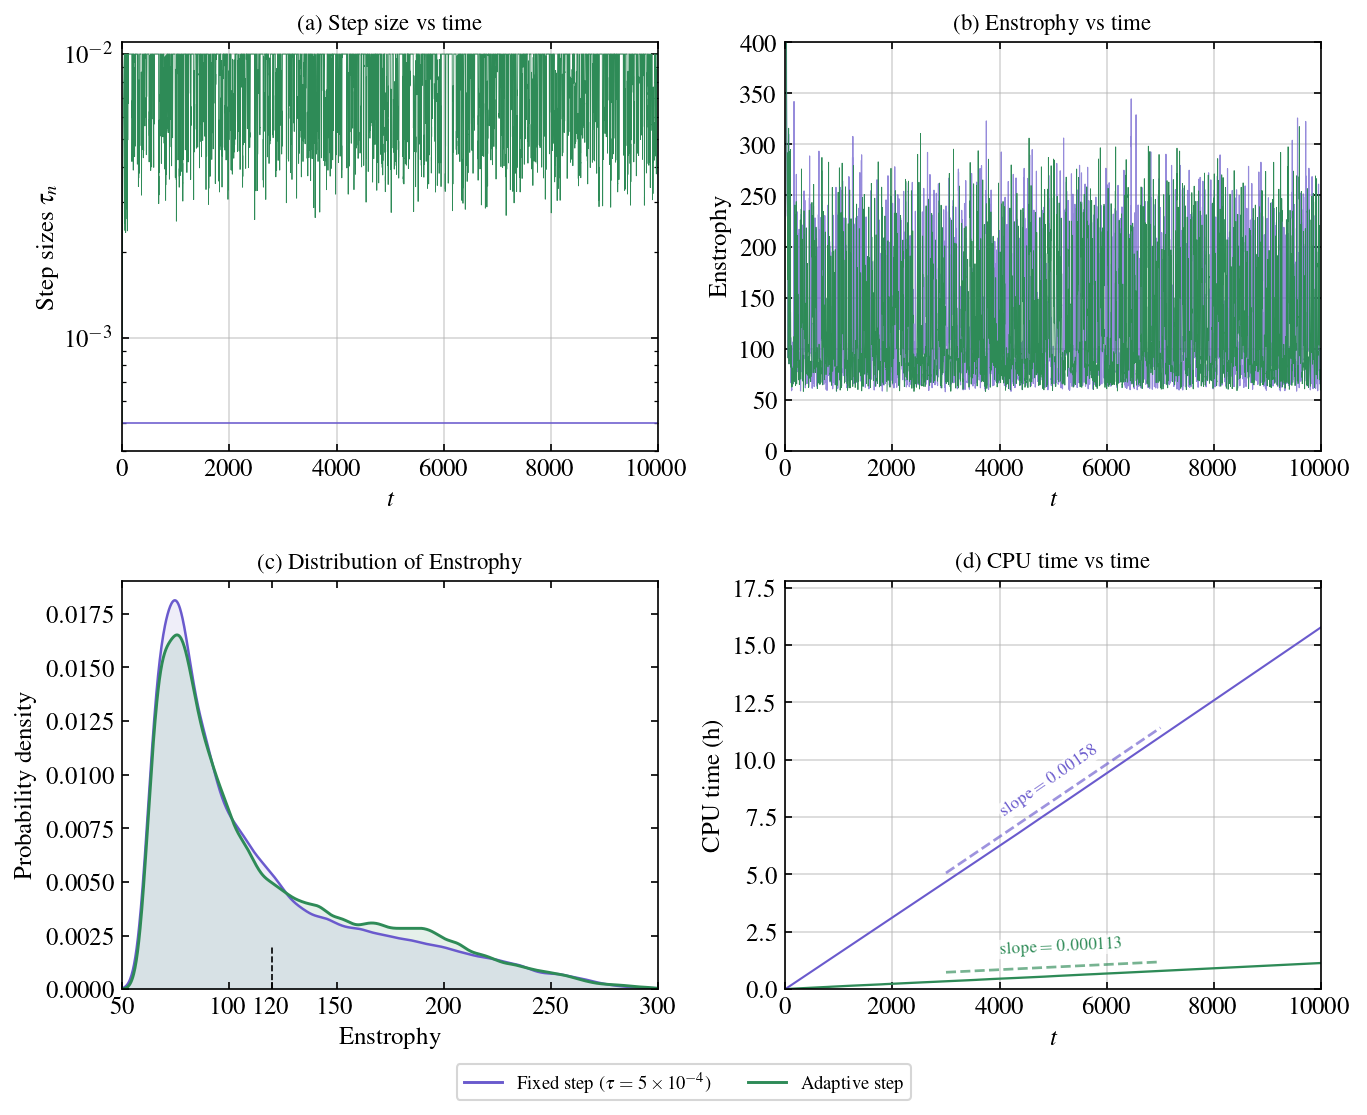

In [23]:
# ── Variable-step 自适应步长诊断：2×2 子图（只比较 5e-4 与 adaptive）──────
#
# (a) 步长 τ 随时间变化
# (b) Enstrophy 随时间变化
# (c) Enstrophy distribution comparison
# (d) 物理时间 t 与 CPU time 的关系

fixed_key = "tau=5e-4"
fixed_plot_specs_1e3 = {fixed_key: fixed_run_specs[fixed_key]}
fixed_spec_1e3 = fixed_plot_specs_1e3[fixed_key]
adaptive_color = adaptive_spec["color"]
adaptive_label = adaptive_spec["label"]

stride = 50
t = tn_vs[::stride]
t_tau = tn_vs[:len(tau_vs):stride]
tau = tau_vs[::stride]
E = Enstrophy_vs[::stride]

if "fixed_pdfs" not in globals() or "pdf_vs" not in globals() or "Z_grid" not in globals():
    from scipy.stats import gaussian_kde
    fixed_kde_data = {}
    fixed_kdes = {}
    fixed_pdfs = {}
    for key, spec in fixed_plot_specs_1e3.items():
        data = spec["data"]
        tau_value = data["tau_value"]
        i0 = int(np.searchsorted(data["tn"], 1000.0, side="left"))
        i1 = int(np.searchsorted(data["tn"], 10000.0, side="right"))
        stride_kde = max(1, int(round(2.0e-2 / tau_value)))
        samples = data["Enstrophy"][i0:i1:stride_kde]
        fixed_kde_data[key] = samples
        fixed_kdes[key] = gaussian_kde(samples)
    mask_vs_kde = (tn_vs >= 1000.0) & (tn_vs <= 10000.0)
    kde_vs = gaussian_kde(
        Enstrophy_vs[mask_vs_kde],
        weights=trapezoidal_point_weights(tn_vs[mask_vs_kde]),
    )
    Z_grid = np.linspace(50, 1500, 2000)
    for key, kde in fixed_kdes.items():
        fixed_pdfs[key] = kde(Z_grid)
    pdf_vs = kde_vs(Z_grid)

fig, axes = plt.subplots(2, 2, figsize=(9, 7), constrained_layout=True, dpi=150)
fig.set_constrained_layout_pads(h_pad=0.05, hspace=0.08)

# ── (a) 步长随时间变化 ──────────────────────────────────────────────────────
ax = axes[0, 0]
tau_fixed = fixed_spec_1e3["data"]["tau_value"]
ax.hlines(
    tau_fixed, 0, 10000,
    color=fixed_spec_1e3["color"], linewidth=0.9, alpha=0.85, linestyle="-",
    rasterized=True,
)
ax.plot(t_tau, tau, color=adaptive_color, linewidth=0.4, rasterized=True)
ax.set_yscale("log")
ax.set_xlim(0, 10000)
ax.set_ylim(4.0e-4, max(1.2e-3, 1.1 * np.nanmax(tau)))
ax.set_xlabel(r"$t$")
ax.set_ylabel(r"Step sizes $\tau_n$")
ax.set_title(r"(a) Step size vs time", loc="center", fontsize=11)
ax.tick_params(which="both", direction="in", top=True, right=True)
ax.grid(alpha=0.5)

# ── (b) Enstrophy 随时间变化 ────────────────────────────────────────────────
ax = axes[0, 1]
data_5e4 = fixed_spec_1e3["data"]
stride_fixed = max(1, len(data_5e4["tn"]) // 20000)
ax.plot(
    data_5e4["tn"][::stride_fixed],
    data_5e4["Enstrophy"][::stride_fixed],
    color=fixed_spec_1e3["color"], alpha=0.70, linewidth=0.55,
    rasterized=True,
)
ax.plot(t, E, color=adaptive_color, linewidth=0.4, rasterized=True)
ax.set_xlim(0, 10000)
ax.set_ylim(0, 400)
ax.set_xlabel(r"$t$")
ax.set_ylabel(r"Enstrophy")
ax.set_title(r"(b) Enstrophy vs time", loc="center", fontsize=11)
ax.tick_params(which="both", direction="in", top=True, right=True)
ax.grid(alpha=0.5)

# ── (c) Enstrophy distribution comparison ────────────────────────────────
ax = axes[1, 0]
ax.vlines(120, 0, 0.002, color="k", linestyles="--", linewidth=0.8)
pdf_5e4 = fixed_pdfs[fixed_key]
ax.fill_between(Z_grid, pdf_5e4, color=fixed_spec_1e3["color"], alpha=0.10, linewidth=0)
ax.plot(Z_grid, pdf_5e4, color=fixed_spec_1e3["color"], linewidth=1.2)
ax.fill_between(Z_grid, pdf_vs, color=adaptive_color, alpha=0.12, linewidth=0)
ax.plot(Z_grid, pdf_vs, color=adaptive_color, linewidth=1.4)
ax.set_xticks([50, 100, 120, 150, 200, 250, 300])
ax.set_xlim(50, 300)
ax.set_ylim(bottom=0)
ax.set_xlabel(r"Enstrophy")
ax.set_ylabel(r"Probability density")
ax.set_title(r"(c) Distribution of Enstrophy", fontsize=11)
ax.tick_params(which="both", direction="in", top=True, right=True)

# ── (d) 物理时间 t 与 CPU time 的关系 ──────────────────────────────────────
ax = axes[1, 1]

cpu_time_scale = 1.0
cpu_time_factors = {
    "adaptive": 1.0,
    "tau=5e-4": 1.0,
}
fit_t0, fit_t1 = 3000.0, 7000.0

def scaled_cpu_hours(cpu_time, factor=1.0):
    return cpu_time / 3600 * cpu_time_scale * factor

def downsample_for_plot(x, target_points=20000):
    return max(1, len(x) // target_points)

def fit_cpu_slope(time, cpu_hours, t0=fit_t0, t1=fit_t1):
    mask = (time >= t0) & (time <= t1)
    if np.count_nonzero(mask) < 2:
        raise ValueError(f"Not enough points to fit CPU slope on [{t0}, {t1}].")
    return np.polyfit(time[mask], cpu_hours[mask], 1)

s_vs = downsample_for_plot(tn_vs)
t_vs_plot = tn_vs[::s_vs]
cpu_vs_hours = scaled_cpu_hours(CPU_vs[::s_vs], factor=cpu_time_factors["adaptive"])
ax.plot(
    t_vs_plot, cpu_vs_hours,
    color=adaptive_color, linewidth=1.1, rasterized=True, linestyle="-",
)

s_fix = downsample_for_plot(data_5e4["tn"])
t_fix_plot = data_5e4["tn"][::s_fix]

cpu_fix_hours = scaled_cpu_hours(
    data_5e4["CPU_time"][::s_fix],
    factor=cpu_time_factors[fixed_key],
)
ax.plot(
    t_fix_plot, cpu_fix_hours,
    color=fixed_spec_1e3["color"], linewidth=1.0, linestyle="-", rasterized=True,
)

k_ada, b_ada = fit_cpu_slope(t_vs_plot, cpu_vs_hours)
k_fix, b_fix = fit_cpu_slope(t_fix_plot, cpu_fix_hours)
ymax_cpu = max(
    np.nanmax(scaled_cpu_hours(CPU_vs, factor=cpu_time_factors["adaptive"])),
    np.nanmax(scaled_cpu_hours(data_5e4["CPU_time"], factor=cpu_time_factors[fixed_key])),
)
fit_line_y_offset = 0.025 * ymax_cpu
t_line = np.array([fit_t0, fit_t1])
label_x = fit_t1 - 3000.0

ax.set_xlim(0, 10000)
ax.set_ylim(0, 1.10 * (ymax_cpu + fit_line_y_offset))

def data_line_angle(ax, slope, intercept, x0, x1, y_offset=0.0):
    p0 = ax.transData.transform((x0, slope * x0 + intercept + y_offset))
    p1 = ax.transData.transform((x1, slope * x1 + intercept + y_offset))
    dx, dy = p1 - p0
    return np.degrees(np.arctan2(dy, dx))

for color, slope, intercept, label_dx in [
    (adaptive_color, k_ada, b_ada, 0.0),
    (fixed_spec_1e3["color"], k_fix, b_fix, 120.0),
]:
    y_line = slope * t_line + intercept + fit_line_y_offset
    ax.plot(t_line, y_line, color=color, linewidth=1.3, linestyle="--", alpha=0.65)
    label_xi = label_x + label_dx
    label_y = slope * label_xi + intercept + fit_line_y_offset
    angle = data_line_angle(ax, slope, intercept, fit_t0, fit_t1, fit_line_y_offset)
    ax.annotate(
        rf"slope $={slope:.3g}$",
        xy=(label_xi, label_y), xytext=(0, 6), textcoords="offset points",
        color=color, fontsize=8.2, ha="left", va="bottom",
        rotation=angle, rotation_mode="anchor",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.70, pad=1.0),
    )

print(f"CPU time scale: ×{cpu_time_scale:g}")
print(f"CPU slope fitting window: [{fit_t0:g}, {fit_t1:g}]")
print(f"Adaptive slope : {k_ada:.4f} h/t  (intercept {b_ada:.3f})")
print(f"{fixed_key:<10} slope : {k_fix:.4f} h/t   speedup vs adaptive: {k_fix/k_ada:.2f}×")

ax.set_xlabel(r"$t$")
ax.set_ylabel(r"CPU time (h)")
ax.set_title(r"(d) CPU time vs time", loc="center", fontsize=11)
ax.tick_params(which="both", direction="in", top=True, right=True)
ax.grid(alpha=0.5)

legend_handles = [
    plt.Line2D([0], [0], color=fixed_spec_1e3["color"], linewidth=1.4, label=fixed_spec_1e3["label"]),
    plt.Line2D([0], [0], color=adaptive_color, linewidth=1.4, label=adaptive_label),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=2, fontsize=9,
           frameon=True, bbox_to_anchor=(0.5, -0.05))

plt.savefig("fig/vs_diagnostics_5e4_adaptive.pdf", dpi=150, bbox_inches="tight")
plt.show()


(50.0, 400.0)

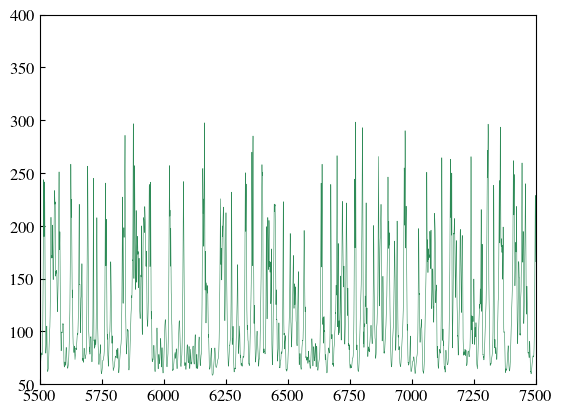

In [14]:
# plt.plot(
#     data_5e4["tn"][::stride_fixed], data_5e4["Enstrophy"][::stride_fixed],
#     color=fixed_spec_5e4["color"], alpha=0.70, linewidth=0.55, rasterized=True)

# plt.hlines(130, 0, 10000, color="k", linestyles="--", linewidth=0.8)
# # plt.hlines(150, 0, 10000, color="k", linestyles="--", linewidth=0.8)
plt.plot(t, E, color=adaptive_color, linewidth=0.4, rasterized=True)
plt.xlim(5500, 7500)
plt.ylim(50, 400)

In [15]:
# ── Bursting 事件统计：连续超过阈值且峰值超过 200 的一段时间算作一个 burst ─────
#
# 对两个固定步长和自适应步长分别统计 burst 事件。

t_cutoff_burst = 500
peak_threshold_burst = 200.0

def empty_burst_result(threshold, peak_threshold):
    empty = np.asarray([])
    return {
        "threshold": threshold,
        "peak_threshold": peak_threshold,
        "start_indices": empty.astype(int),
        "end_indices": empty.astype(int),
        "start_times": empty,
        "end_times": empty,
        "durations": empty,
        "time_intervals": empty,
        "clean_time_intervals": empty,
        "clean_interval_mask": np.asarray([], dtype=bool),
        "peak_values": empty,
        "count": 0,
        "clean_interval_count": 0,
        "max_duration": np.nan,
        "mean_duration": np.nan,
        "mean_interval": np.nan,
        "mean_clean_interval": np.nan,
    }

def detect_burst_segments(t, E, threshold, t_cutoff=0, peak_threshold=peak_threshold_burst):
    mask = t >= t_cutoff
    t_ss = t[mask]
    E_ss = E[mask]

    above = E_ss > threshold
    if not np.any(above):
        return empty_burst_result(threshold, peak_threshold)

    padded = np.r_[False, above, False]
    transitions = np.diff(padded.astype(np.int8))
    start_indices_all = np.flatnonzero(transitions == 1)
    end_indices_all = np.flatnonzero(transitions == -1) - 1
    peak_values_all = np.asarray([
        np.max(E_ss[i0:i1 + 1]) for i0, i1 in zip(start_indices_all, end_indices_all)
    ])

    keep = peak_values_all > peak_threshold
    if not np.any(keep):
        return empty_burst_result(threshold, peak_threshold)

    start_indices = start_indices_all[keep]
    end_indices = end_indices_all[keep]
    peak_values = peak_values_all[keep]

    start_times = t_ss[start_indices]
    end_times = t_ss[end_indices]
    durations = end_times - start_times
    time_intervals = np.diff(start_times)
    clean_interval_mask = np.asarray([
        not np.any(above[i_end + 1:i_next])
        for i_end, i_next in zip(end_indices[:-1], start_indices[1:])
    ], dtype=bool)
    clean_time_intervals = np.asarray([
        t_ss[i_next] - t_ss[i_end]
        for i_end, i_next in zip(end_indices[:-1], start_indices[1:])
    ])[clean_interval_mask]

    return {
        "threshold": threshold,
        "peak_threshold": peak_threshold,
        "start_indices": start_indices,
        "end_indices": end_indices,
        "start_times": start_times,
        "end_times": end_times,
        "durations": durations,
        "time_intervals": time_intervals,
        "clean_time_intervals": clean_time_intervals,
        "clean_interval_mask": clean_interval_mask,
        "peak_values": peak_values,
        "count": len(durations),
        "clean_interval_count": len(clean_time_intervals),
        "max_duration": np.max(durations),
        "mean_duration": np.mean(durations),
        "mean_interval": np.mean(time_intervals) if len(time_intervals) else np.nan,
        "mean_clean_interval": np.mean(clean_time_intervals) if len(clean_time_intervals) else np.nan,
    }

if "steady_moments_fixed" not in globals() or "steady_moments_vs" not in globals():
    def weighted_moments(x, w=None):
        mu1 = np.average(x, weights=w)
        mu2 = np.average(x**2, weights=w)
        var = np.average((x - mu1)**2, weights=w)
        std = np.sqrt(var)
        return mu1, mu2, var, std

    steady_moments_fixed = {}
    for key, spec in fixed_run_specs.items():
        data = spec["data"]
        i0 = int(np.searchsorted(data["tn"], 1000, side="left"))
        samples = data["Enstrophy"][i0:]
        mu1, mu2, var, std = weighted_moments(samples)
        steady_moments_fixed[key] = {
            "samples": samples,
            "mean": mu1,
            "second_moment": mu2,
            "variance": var,
            "std": std,
        }

    mask_vs_mom = tn_vs >= 1000
    E_vs_ss = Enstrophy_vs[mask_vs_mom]
    w_vs = trapezoidal_point_weights(tn_vs[mask_vs_mom])
    mu1_vs, mu2_vs, var_vs, std_vs = weighted_moments(E_vs_ss, w=w_vs)
    steady_moments_vs = {
        "samples": E_vs_ss,
        "weights": w_vs,
        "mean": mu1_vs,
        "second_moment": mu2_vs,
        "variance": var_vs,
        "std": std_vs,
    }

burst_fixed = {}
for key, spec in fixed_run_specs.items():
    threshold = steady_moments_fixed[key]["mean"] + 2 * steady_moments_fixed[key]["std"]
    burst_fixed[key] = detect_burst_segments(
        spec["data"]["tn"], spec["data"]["Enstrophy"],
        threshold=threshold, t_cutoff=t_cutoff_burst,
    )

burst_vs = detect_burst_segments(
    tn_vs, Enstrophy_vs,
    threshold=steady_moments_vs["mean"] + 2 * steady_moments_vs["std"],
    t_cutoff=t_cutoff_burst,
)

# Backward-compatible default fixed-step alias.
burst_fs = burst_fixed[default_fs_key]

k_values_burst = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
burst_count_rows = []
for k in k_values_burst:
    threshold_vs = steady_moments_vs["mean"] + k * steady_moments_vs["std"]
    burst_k_vs = detect_burst_segments(tn_vs, Enstrophy_vs, threshold_vs, t_cutoff_burst)
    for key, spec in fixed_run_specs.items():
        threshold_fixed = steady_moments_fixed[key]["mean"] + k * steady_moments_fixed[key]["std"]
        burst_k_fixed = detect_burst_segments(
            spec["data"]["tn"], spec["data"]["Enstrophy"],
            threshold_fixed, t_cutoff_burst,
        )
        fixed_count = burst_k_fixed["count"]
        adaptive_count = burst_k_vs["count"]
        count_error_pct = 100 * abs(fixed_count - adaptive_count) / fixed_count if fixed_count > 0 else np.nan
        burst_count_rows.append({
            "k": k,
            "fixed run": key,
            "fixed threshold": threshold_fixed,
            "fixed burst count": fixed_count,
            "adaptive threshold": threshold_vs,
            "adaptive burst count": adaptive_count,
            "count error (%)": count_error_pct,
        })

try:
    import pandas as pd
    burst_count_table = pd.DataFrame(burst_count_rows)
    display(burst_count_table.style.format({
        "k": "{:.1f}",
        "fixed threshold": "{:.4f}",
        "adaptive threshold": "{:.4f}",
        "count error (%)": "{:.2f}",
    }))
except ImportError:
    burst_count_table = burst_count_rows
    print(f"{'k':>4} {'fixed run':>10} {'fixed thr.':>14} {'fixed':>8} {'adapt thr.':>14} {'adapt':>8} {'err (%)':>9}")
    print("-" * 86)
    for row in burst_count_rows:
        print(
            f"{row['k']:>4.1f} {row['fixed run']:>10} {row['fixed threshold']:>14.4f} "
            f"{row['fixed burst count']:>8d} {row['adaptive threshold']:>14.4f} "
            f"{row['adaptive burst count']:>8d} {row['count error (%)']:>9.2f}"
        )

def print_burst_duration_summary(label, burst):
    if burst["count"] == 0:
        print(
            f"{label} threshold = {burst['threshold']:.4f}, "
            f"peak > {burst['peak_threshold']:.1f}, count = 0"
        )
        return

    i_max = int(np.argmax(burst["durations"]))
    print(
        f"{label} threshold = {burst['threshold']:.4f}, "
        f"peak > {burst['peak_threshold']:.1f}, count = {burst['count']}"
    )
    print(f"  max duration  = {burst['max_duration']:.4f} "
          f"on [{burst['start_times'][i_max]:.4f}, {burst['end_times'][i_max]:.4f}], "
          f"peak = {burst['peak_values'][i_max]:.4f}")
    print(f"  mean duration = {burst['mean_duration']:.4f}")
    print(f"  mean interval = {burst['mean_interval']:.4f}")
    print(
        f"  clean intervals = {burst['clean_interval_count']}/{max(burst['count'] - 1, 0)}, "
        f"mean clean interval = {burst['mean_clean_interval']:.4f}"
    )

for key, spec in fixed_run_specs.items():
    print_burst_duration_summary(spec["label"], burst_fixed[key])
print_burst_duration_summary(adaptive_spec["label"], burst_vs)


,k,fixed run,fixed threshold,fixed burst count,adaptive threshold,adaptive burst count,count error (%)
0,1.0,tau=1e-3,166.2841,278,166.4893,301,8.27
1,1.0,tau=5e-4,162.7025,282,166.4893,301,6.74
2,2.0,tau=1e-3,216.6691,286,216.5396,278,2.80
3,2.0,tau=5e-4,212.0473,291,216.5396,278,4.47
4,3.0,tau=1e-3,267.0540,70,266.5898,59,15.71
5,3.0,tau=5e-4,261.3920,79,266.5898,59,25.32
6,4.0,tau=1e-3,317.4390,5,316.6400,1,80.00
7,4.0,tau=5e-4,310.7367,6,316.6400,1,83.33
8,5.0,tau=1e-3,367.8239,0,366.6903,0,nan
9,5.0,tau=5e-4,360.0815,0,366.6903,0,nan


Fixed step ($\tau=10^{-3}$) threshold = 216.6691, peak > 200.0, count = 286
  max duration  = 8.4980 on [3212.8330, 3221.3310], peak = 287.9836
  mean duration = 2.0092
  mean interval = 33.0641
  clean intervals = 285/285, mean clean interval = 31.0609
Fixed step ($\tau=5\times10^{-4}$) threshold = 212.0473, peak > 200.0, count = 291
  max duration  = 8.9790 on [6816.8750, 6825.8540], peak = 292.8396
  mean duration = 2.0012
  mean interval = 32.4713
  clean intervals = 290/290, mean clean interval = 30.4791
Adaptive step threshold = 216.5396, peak > 200.0, count = 278
  max duration  = 7.4655 on [9373.3128, 9380.7783], peak = 298.5086
  mean duration = 1.8219
  mean interval = 34.2923
  clean intervals = 277/277, mean clean interval = 32.4675


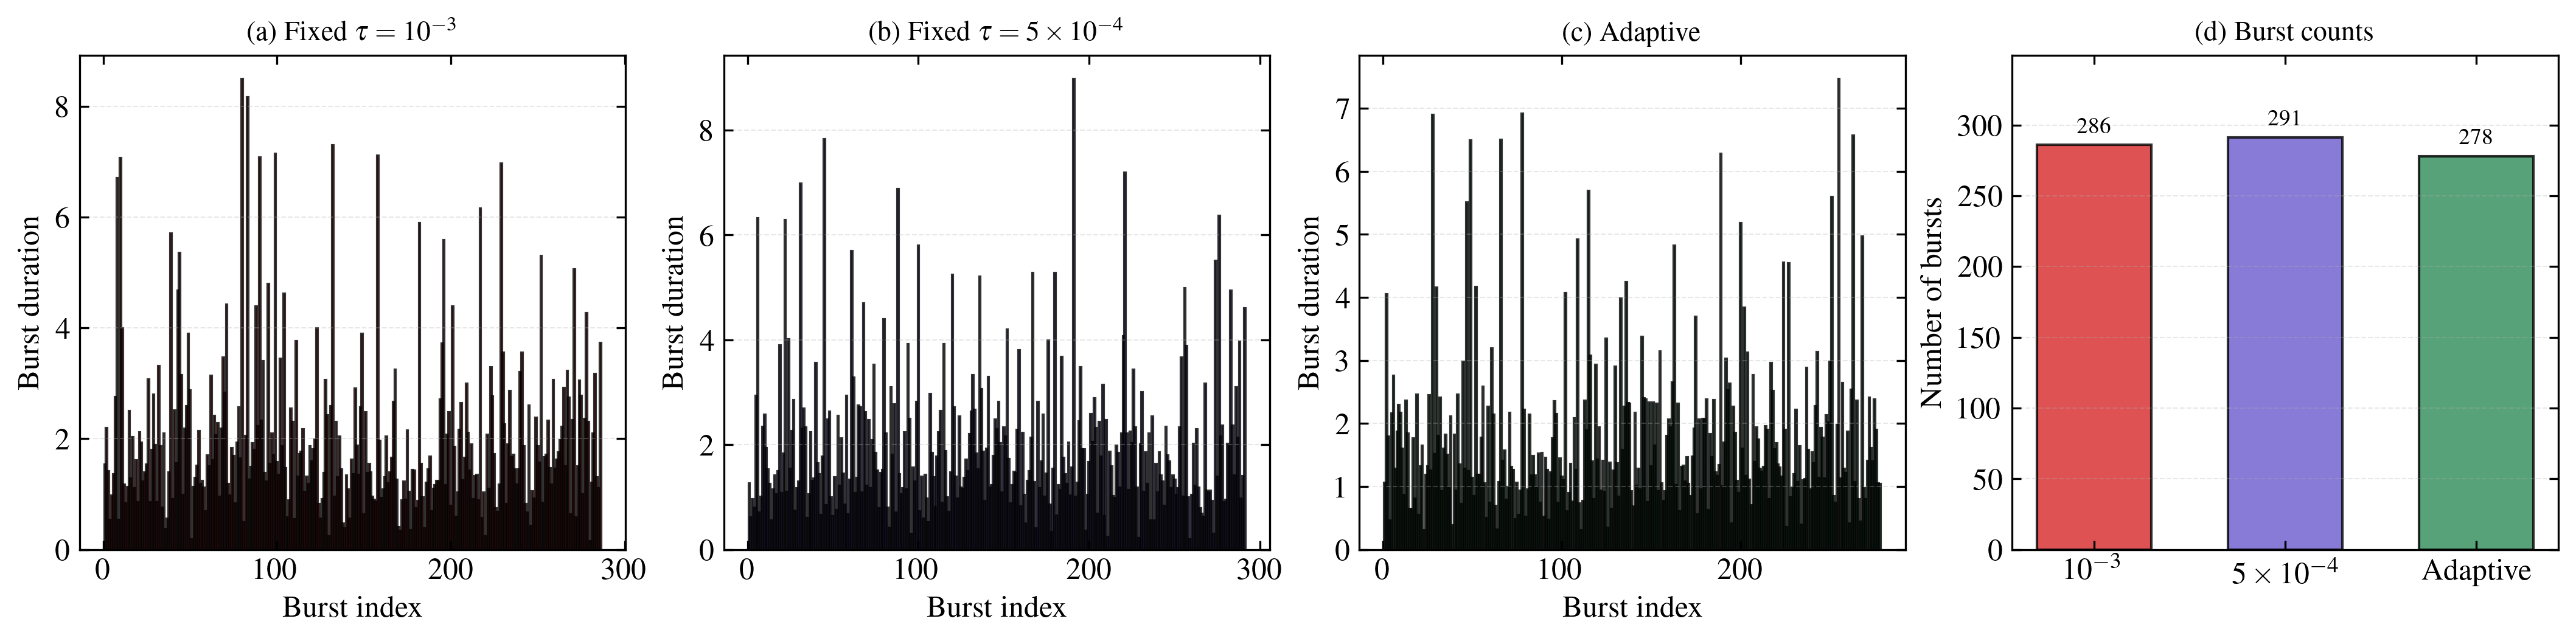

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.4), constrained_layout=True, dpi=300)

# ── (a)-(c) Burst duration bar plots ──────────────────────────────────────
duration_panels = [
    ("tau=1e-3", fixed_run_specs["tau=1e-3"], burst_fixed["tau=1e-3"], r"(a) Fixed $\tau=10^{-3}$"),
    ("tau=5e-4", fixed_run_specs["tau=5e-4"], burst_fixed["tau=5e-4"], r"(b) Fixed $\tau=5\times10^{-4}$"),
    ("adaptive", adaptive_spec, burst_vs, r"(c) Adaptive"),
]

for ax, (_, spec, burst, title) in zip(axes[:3], duration_panels):
    durations = burst["durations"]
    x_pos = np.arange(1, len(durations) + 1)
    ax.bar(x_pos, durations, color=spec["color"],
           edgecolor="black", alpha=0.8, width=0.6)
    ax.set_xlabel(r"Burst index")
    ax.set_ylabel(r"Burst duration")
    ax.set_title(title, fontsize=11)
    ax.tick_params(which="both", direction="in", top=True, right=True)
    ax.grid(axis="y", alpha=0.3, linestyle="dashed", linewidth=0.5)

# ── (d) Burst count comparison ───────────────────────────────────────────
ax = axes[3]
labels = [r"$10^{-3}$", r"$5\times10^{-4}$", r"Adaptive"]
counts = [burst_fixed["tau=1e-3"]["count"], burst_fixed["tau=5e-4"]["count"], burst_vs["count"]]
colors = [fixed_run_specs["tau=1e-3"]["color"], fixed_run_specs["tau=5e-4"]["color"], adaptive_spec["color"]]
x = np.arange(len(labels))
bars = ax.bar(x, counts, color=colors, edgecolor="black", alpha=0.8, width=0.6)
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_ylim(0, max(counts) * 1.20 if counts else 1)
ax.set_xticks(x, labels)
ax.set_ylabel(r"Number of bursts")
ax.set_title(r"(d) Burst counts", fontsize=11)
ax.tick_params(which="both", direction="in", top=True, right=True)
ax.grid(axis="y", alpha=0.3, linestyle="dashed", linewidth=0.5)

from pathlib import Path
Path("fig").mkdir(exist_ok=True)
plt.savefig("fig/bursting_event_comparison.pdf", dpi=300, bbox_inches="tight", pad_inches=0.2)
plt.show()

## 当前长期稳定性实验总结

本 Notebook 比较二维周期 Navier--Stokes 爆发流中两组固定步长计算与一组自适应步长计算。三组数据均使用 `SDIRK2_mr_SAV` 方法，参数为

\[
Re=30,\qquad \nu=1/30,\qquad m=3,\qquad \varepsilon=4,
\qquad \bar C=1000,
\]

空间区域为 $[0,2\pi]^2$，网格为 $128\times128$，终止时间为 $T=10000$。固定步长分别为 $\tau=10^{-3}$ 和 $\tau=5\times10^{-4}$；自适应计算实际采用的步长范围为 $5\times10^{-4}\leq\tau_n\leq10^{-2}$，共完成 1,359,950 个时间步。除特别说明外，长期统计窗口取 $1000\leq t\leq10000$，自适应轨迹的时间平均采用非均匀时间网格的梯形节点权重。

### 代表性流动尺度

从统计窗口内的时间平均动能定义

\[
U=\sqrt{\frac{2\langle E\rangle}{L^2}},\qquad
Re_U=\frac{UL}{\nu},\qquad
T_e=\frac{L}{U},\qquad L=2\pi.
\]

| Quantity | Fixed $10^{-3}$ | Fixed $5\times10^{-4}$ | Adaptive |
|---|---:|---:|---:|
| $U$ | 1.346111 | 1.342826 | 1.344536 |
| $Re_U$ | 338.314501 | 337.489029 | 337.918640 |
| $T_e$ | 4.667659 | 4.679076 | 4.673127 |
| $\langle E\rangle$ | 35.767719 | 35.593389 | 35.684065 |

自适应结果相对两个固定步长基线的差异均不超过 $0.26\%$。

### 自适应步长响应

在 $t\geq1000$ 上，步长与 Enstrophy、Palinstrophy 的 Pearson 相关系数分别为 $-0.5581$ 和 $-0.6451$；对应的时间加权相关系数为 $-0.5489$ 和 $-0.6332$。这表明控制器会在流动活动增强时减小步长，在相对平静阶段增大步长。

### Enstrophy 长期统计

| Statistic | Fixed $10^{-3}$ | Fixed $5\times10^{-4}$ | Adaptive |
|---|---:|---:|---:|
| Mean | 115.8992 | 113.3578 | 116.4391 |
| Second moment | 15971.2661 | 15284.8955 | 16063.0899 |
| Variance | 2538.6423 | 2434.9027 | 2505.0259 |
| Standard deviation | 50.3849 | 49.3447 | 50.0502 |

在 $0\leq\mathcal E<500$ 上，自适应 KDE 与两个固定步长 KDE 的总变差距离分别为 0.0350 和 0.0372；两个固定步长结果之间的总变差距离为 0.0329。因此，自适应与固定步长之间的分布差异和两个固定步长基线自身的差异处于同一量级。

### 爆发事件

爆发阈值取每条轨迹各自的 $\mathbb E[\mathcal E]+2\operatorname{Std}(\mathcal E)$，并要求事件峰值大于 200；事件搜索从 $t=500$ 开始。

| Run | Threshold | Count | Mean duration | Mean start interval |
|---|---:|---:|---:|---:|
| Fixed $10^{-3}$ | 216.6691 | 286 | 2.0092 | 33.0641 |
| Fixed $5\times10^{-4}$ | 212.0473 | 291 | 2.0012 | 32.4713 |
| Adaptive | 216.5396 | 278 | 1.8219 | 34.2923 |

自适应计算相对两个固定步长基线的爆发次数差异分别为 $2.80\%$ 和 $4.47\%$。

### 计算成本

三组数据均为 $128^2$ 网格，因此直接比较记录的 CPU 时间，不再进行分辨率缩放或人为校准：

| Run | Steps | Recorded CPU time |
|---|---:|---:|
| Fixed $10^{-3}$ | 10,000,000 | 7.998 h |
| Fixed $5\times10^{-4}$ | 20,000,000 | 15.781 h |
| Adaptive | 1,359,950 | 1.141 h |

在 $3000\leq t\leq7000$ 上拟合累计 CPU 时间斜率后，自适应计算相对两个固定步长基线的加速比分别为 7.06 和 13.99。

综合来看，自适应 `SDIRK2_mr_SAV` 在显著降低时间步数和计算成本的同时，较好保持了代表性流动尺度、Enstrophy 概率分布以及间歇爆发频率。